/Users/zaxhyperson/Downloads/NASGOL/rebuttal/venv_rebuttal/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Generating Data...
Searching for failure case...
Trial 1... Acc: 100.00%
 -> Captured SUCCESS model
Trial 2... Acc: 100.00%
Trial 3... Acc: 100.00%
Trial 4... Acc: 100.00%
Trial 5... Acc: 100.00%
Trial 6... Acc: 100.00%
Trial 7... Acc: 100.00%
Trial 8... Acc: 100.00%
Trial 9... Acc: 100.00%
Trial 10... Acc: 100.00%
Trial 11... Acc: 100.00%
Trial 12... Acc: 100.00%
Trial 13... Acc: 100.00%
Trial 14... Acc: 1.50%
 -> Captured FAILED model

Analyzing Successful Model...
Saved plot to kan_success.png
--- Weights for Success ---
Layer 1 (Filter 1): 0.9652x^2 + 0.9495x + -1.2105
Layer 1 (Filter 2): 0.1024x^2 + 1.1774x + -0.4799
Layer 2 (Filter 1): 1.1935x^2 + -0.2663x + -1.1781
---------------------------

Analyzing Failed Model...
Saved plot to kan_failure.png
--- Weights for Failure ---
Layer 1 (Filter 1): 1.1320x^2 + -0.6940x + 0.1812
Layer 1 (Filter 2): -0.3545x^2 + 0.9797x + 0.1705
Layer 2 (Filter 1): 0.6267x^2 + 1.0467x + 0.0354
---------------------------


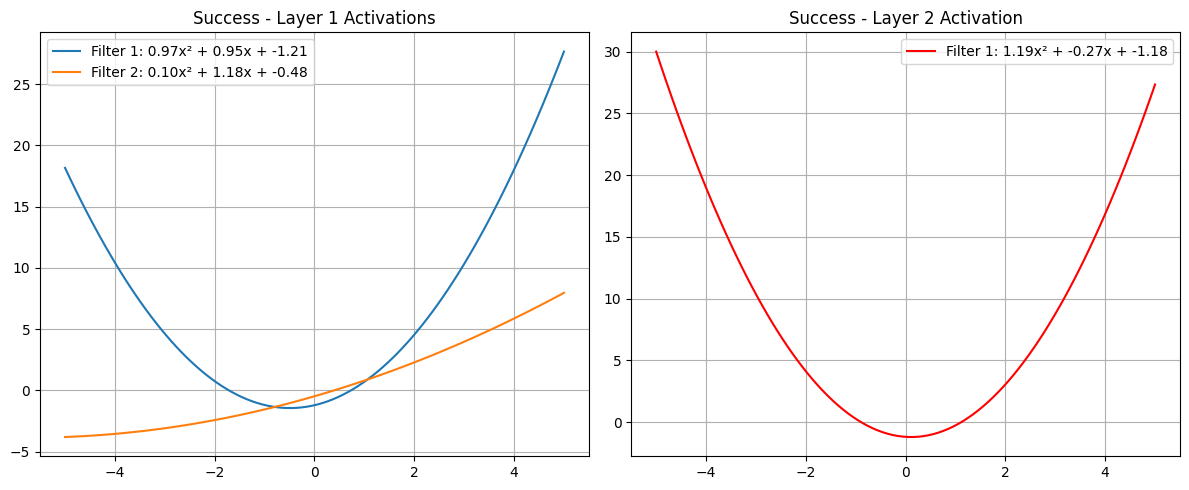

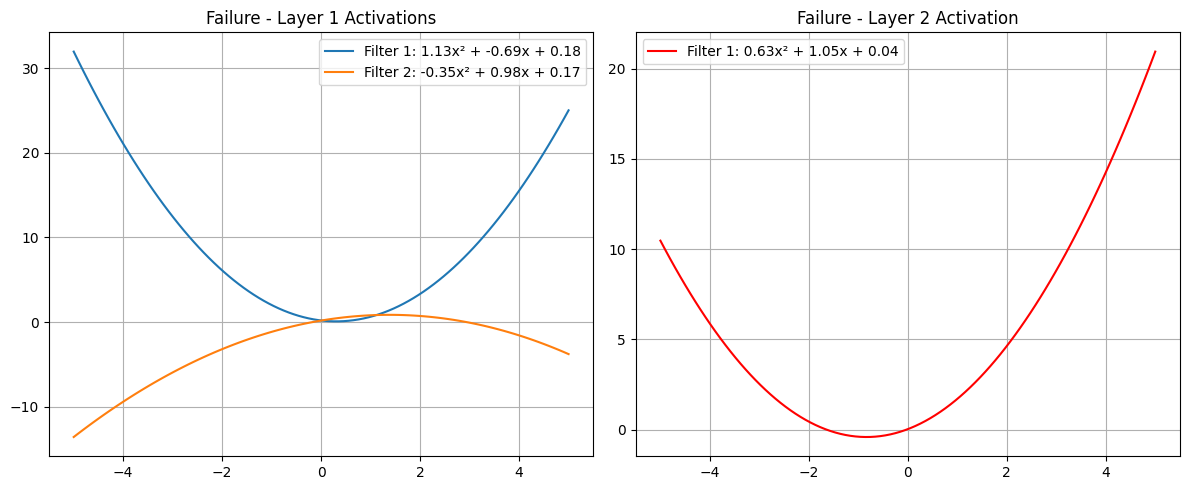

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from scipy.signal import convolve2d
import os
import matplotlib.pyplot as plt

# Suppress TF logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

def game_of_life_step(grid):
    kernel = np.array([[1, 1, 1],
                       [1, 0, 1],
                       [1, 1, 1]])
    neighbors = convolve2d(grid, kernel, mode='same', boundary='fill', fillvalue=0)
    survives = (grid == 1) & ((neighbors == 2) | (neighbors == 3))
    births = (grid == 0) & (neighbors == 3)
    return (survives | births).astype(np.float32)

def generate_data(num_samples, grid_size):
    X = np.zeros((num_samples, grid_size, grid_size, 1), dtype=np.float32)
    y = np.zeros((num_samples, grid_size, grid_size, 1), dtype=np.float32)

    for i in range(num_samples):
        density = np.random.uniform(0.1, 0.9)
        state = np.random.choice([0, 1], size=(grid_size, grid_size), p=[1-density, density])
        next_state = game_of_life_step(state)
        X[i, :, :, 0] = state
        y[i, :, :, 0] = next_state
        
    return X, y

GRID_SIZE = 20
NUM_TRAIN = 5000 # Reduced for speed, should be enough
NUM_VAL = 1000

print("Generating Data...")
X_train, y_train = generate_data(NUM_TRAIN, GRID_SIZE)
X_val, y_val = generate_data(NUM_VAL, GRID_SIZE)

class QuadraticActivation(layers.Layer):
    def __init__(self, **kwargs):
        super(QuadraticActivation, self).__init__(**kwargs)

    def build(self, input_shape):
        num_channels = input_shape[-1]
        self.w2 = self.add_weight(name='w2', shape=(1, 1, 1, num_channels), initializer='zeros', trainable=True)
        self.w1 = self.add_weight(name='w1', shape=(1, 1, 1, num_channels), initializer='ones', trainable=True)
        self.w0 = self.add_weight(name='w0', shape=(1, 1, 1, num_channels), initializer='zeros', trainable=True)
        
    def call(self, inputs):
        return self.w2 * tf.square(inputs) + self.w1 * inputs + self.w0

def build_model():
    inputs = layers.Input(shape=(GRID_SIZE, GRID_SIZE, 1))
    x = layers.Conv2D(2, (3, 3), padding='same')(inputs)
    x = QuadraticActivation(name='quad1')(x) 
    x = layers.Conv2D(1, (1, 1), padding='same')(x)
    x = QuadraticActivation(name='quad2')(x)
    outputs = layers.Conv2D(1, (1, 1), padding='same', activation='sigmoid')(x)
    return models.Model(inputs=inputs, outputs=outputs)

def evaluate_exact_match(model, X, y):
    preds = model.predict(X, verbose=0)
    preds_binary = (preds > 0.5).astype(np.float32)
    matches = np.all(preds_binary == y, axis=(1, 2, 3))
    return np.mean(matches)

success_model = None
failed_model = None

print("Searching for failure case...")
max_trials = 20
for i in range(max_trials):
    print(f"Trial {i+1}...", end="", flush=True)
    model = build_model()
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Fast training
    model.fit(X_train, y_train, epochs=30, batch_size=64, verbose=0)
    
    acc = evaluate_exact_match(model, X_val, y_val)
    print(f" Acc: {acc*100:.2f}%")
    
    if acc > 0.99 and success_model is None:
        success_model = model
        print(" -> Captured SUCCESS model")
    
    if acc < 0.50 and failed_model is None: # Assuming failure is catastrophic
        failed_model = model
        print(" -> Captured FAILED model")
        
    if success_model and failed_model:
        break

if not failed_model:
    print("Could not reproduce failure in 20 trials! Using last model as 'failed' proxy (if low acc) or aborting.")
    if acc < 0.99:
        failed_model = model
    else:
        print("All trials succeeded. Cannot analyze failure.")
        exit()

# Analysis
def plot_activations(model, title, filename):
    # Get weights
    quad1 = model.get_layer('quad1')
    quad2 = model.get_layer('quad2')
    
    # Layer 1 (2 filters)
    w2_1 = quad1.w2.numpy().flatten()
    w1_1 = quad1.w1.numpy().flatten()
    w0_1 = quad1.w0.numpy().flatten()
    
    # Layer 2 (1 filter)
    w2_2 = quad2.w2.numpy().flatten()
    w1_2 = quad2.w1.numpy().flatten()
    w0_2 = quad2.w0.numpy().flatten()
    
    x = np.linspace(-5, 5, 100)
    
    plt.figure(figsize=(12, 5))
    
    # Plot Layer 1
    plt.subplot(1, 2, 1)
    for i in range(2):
        y = w2_1[i] * x**2 + w1_1[i] * x + w0_1[i]
        plt.plot(x, y, label=f'Filter {i+1}: {w2_1[i]:.2f}x² + {w1_1[i]:.2f}x + {w0_1[i]:.2f}')
    plt.title(f'{title} - Layer 1 Activations')
    plt.legend()
    plt.grid(True)
    
    # Plot Layer 2
    plt.subplot(1, 2, 2)
    y = w2_2[0] * x**2 + w1_2[0] * x + w0_2[0]
    plt.plot(x, y, label=f'Filter 1: {w2_2[0]:.2f}x² + {w1_2[0]:.2f}x + {w0_2[0]:.2f}', color='red')
    plt.title(f'{title} - Layer 2 Activation')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(filename)
    print(f"Saved plot to {filename}")
    
    print(f"--- Weights for {title} ---")
    print(f"Layer 1 (Filter 1): {w2_1[0]:.4f}x^2 + {w1_1[0]:.4f}x + {w0_1[0]:.4f}")
    print(f"Layer 1 (Filter 2): {w2_1[1]:.4f}x^2 + {w1_1[1]:.4f}x + {w0_1[1]:.4f}")
    print(f"Layer 2 (Filter 1): {w2_2[0]:.4f}x^2 + {w1_2[0]:.4f}x + {w0_2[0]:.4f}")
    print("---------------------------")

print("\nAnalyzing Successful Model...")
plot_activations(success_model, "Success", "kan_success.png")

print("\nAnalyzing Failed Model...")
plot_activations(failed_model, "Failure", "kan_failure.png")